In [1]:
import mne
import matplotlib.pyplot as plt

In [2]:
file_path = r"C:\users\Prajapati_Shivam\EEG-Seizure-Detection\data\chb01\chb01_01.edf"
raw = mne.io.read_raw_edf(file_path, preload = True)
print(raw)

Extracting EDF parameters from C:\users\Prajapati_Shivam\EEG-Seizure-Detection\data\chb01\chb01_01.edf...
Setting channel info structure...
Creating raw.info structure...


C:\Users\Prajapati_Shivam\AppData\Local\Temp\ipykernel_10500\2590529430.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload = True)


Reading 0 ... 921599  =      0.000 ...  3599.996 secs...
<RawEDF | chb01_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>


In [3]:
raw_filtered = raw.copy()

In [4]:
raw_filtered.filter(l_freq=0.5, h_freq=40)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)



<RawEDF | chb01_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

In [5]:
print("Original Data Shape :", raw.get_data().shape)

Original Data Shape : (23, 921600)


In [6]:
print("Filtered Data Shape :", raw_filtered.get_data().shape)

Filtered Data Shape : (23, 921600)


In [7]:
import matplotlib.pyplot as plt

In [8]:
original = raw.get_data()

In [9]:
filtered = raw_filtered.get_data()

In [10]:
sfreq = int(raw.info["sfreq"])

In [11]:
samples = 10*sfreq

In [12]:
plt.figure(figsize=(15,5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

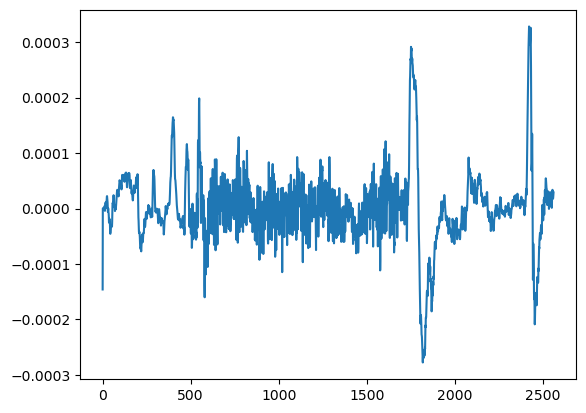

In [13]:
plt.plot(original[0][:samples], label="Original EEG")

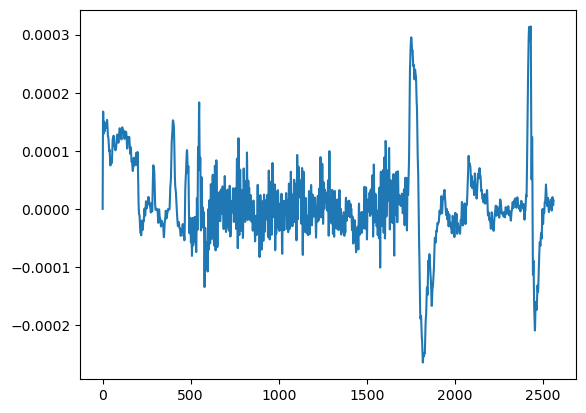

In [14]:
plt.plot(filtered[0][:samples], label="Filtered EEG")

Text(0.5, 1.0, 'Original vs Filtered EEG (First Channel)')

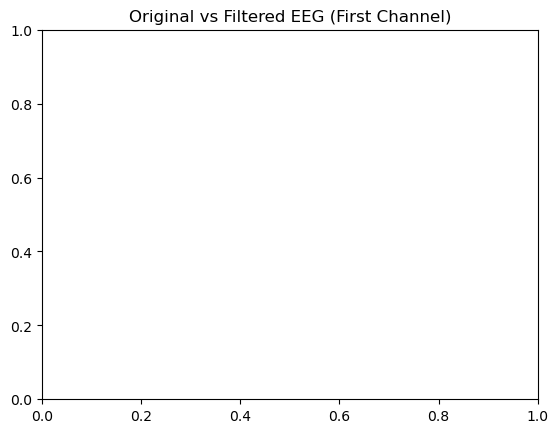

In [15]:
plt.title("Original vs Filtered EEG (First Channel)")

Text(0.5, 0, 'Samples')

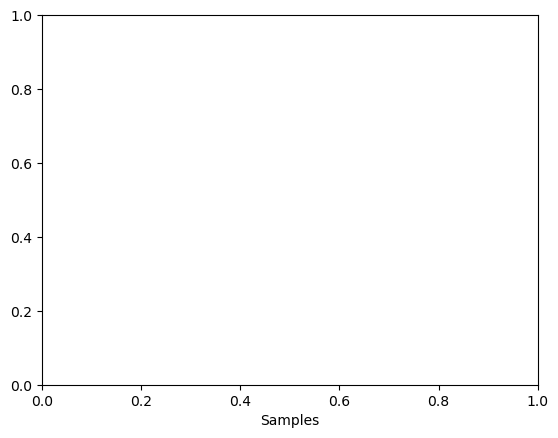

In [16]:
plt.xlabel("Samples")

Text(0, 0.5, 'Amplitude')

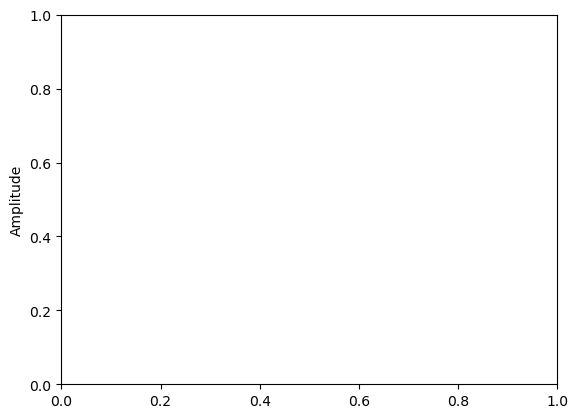

In [17]:
plt.ylabel("Amplitude")

C:\Users\Prajapati_Shivam\AppData\Local\Temp\ipykernel_10500\4061938096.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


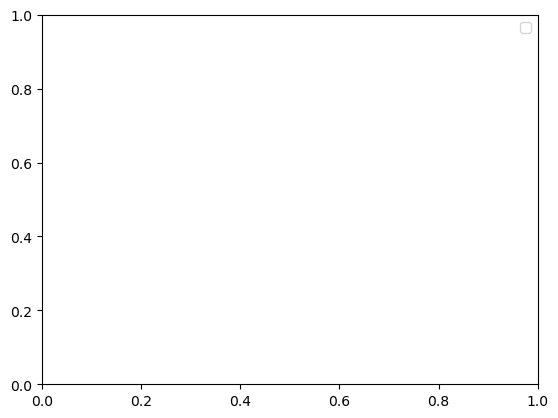

In [18]:
plt.legend()

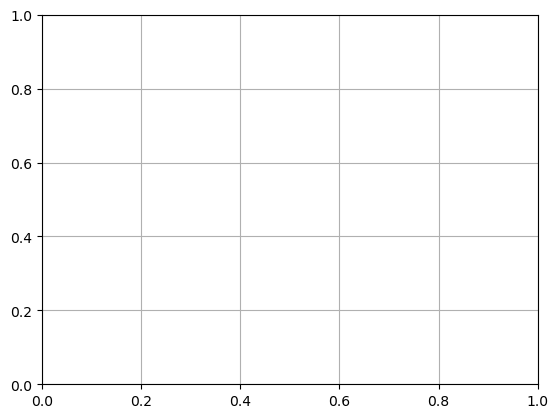

In [19]:
plt.grid(True)

In [20]:
plt.show()

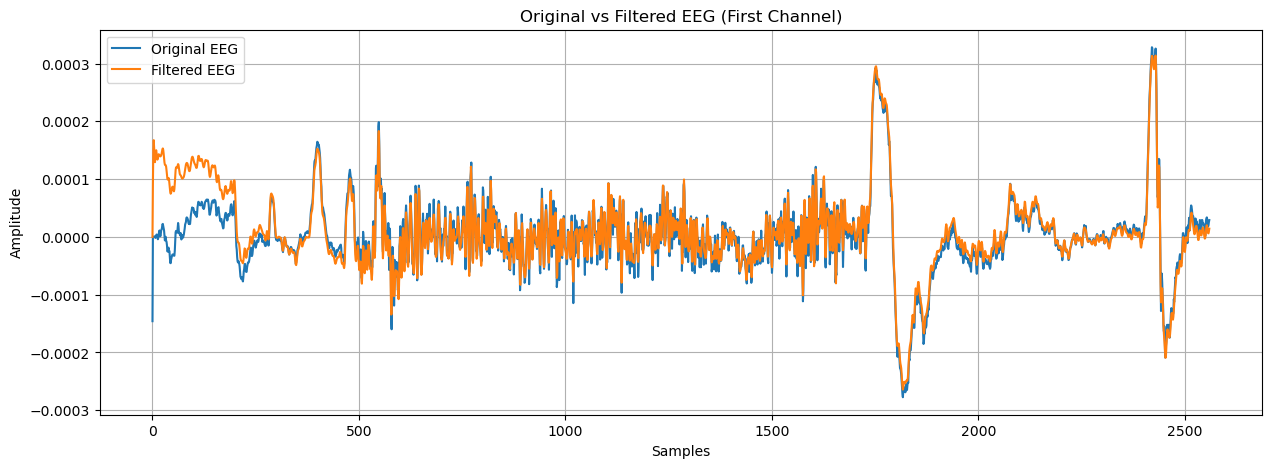

In [22]:
import matplotlib.pyplot as plt

# Get original data
original = raw.get_data()

# Get filtered data
filtered = raw_filtered.get_data()

# Sampling frequency
sfreq = int(raw.info["sfreq"])

# First 10 seconds
samples = 10 * sfreq

plt.figure(figsize=(15,5))

plt.plot(original[0][:samples], label="Original EEG")

plt.plot(filtered[0][:samples], label="Filtered EEG")

plt.title("Original vs Filtered EEG (First Channel)")

plt.xlabel("Samples")

plt.ylabel("Amplitude")

plt.legend()

plt.grid(True)

plt.show()

In [23]:
raw_notch = raw_filtered.copy()

In [25]:
raw_notch.notch_filter(freqs=50)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1691 samples (6.605 s)



<RawEDF | chb01_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

In [26]:
import matplotlib.pyplot as plt


In [27]:
filtered = raw_filtered.get_data()
notched = raw_notch.get_data()

In [28]:
sfreq = int(raw.info["sfreq"])

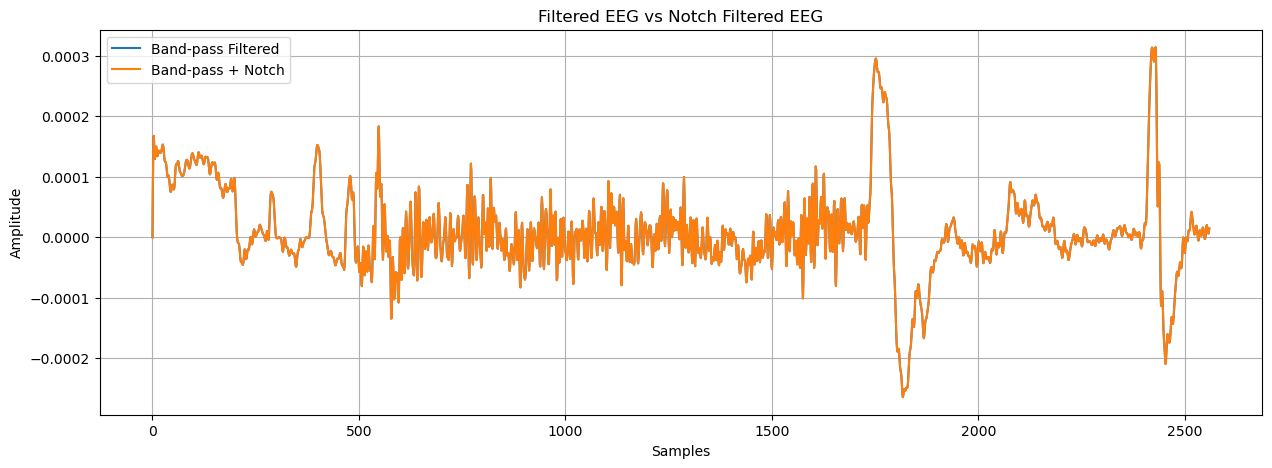

In [30]:
samples = 10*sfreq

plt.figure(figsize=(15,5))

plt.plot(filtered[0][:samples], label="Band-pass Filtered")
plt.plot(notched[0][:samples], label="Band-pass + Notch")

plt.title("Filtered EEG vs Notch Filtered EEG")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()
